# DVFM subject-level frailty calibration

This notebook fits an affine mapping on the validation split only,

\[
\widehat z_i = \alpha + \beta\,\mu_i^{\mathrm{aligned}},
\]

and applies that fixed mapping to the test split. It visualizes both the uncalibrated DVFM latent and the calibrated latent against the known standardized log-frailty.

The test set is never used to fit the mapping.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Change this to the experiment output directory when needed.
OUTPUT_DIR = Path("../outputs/semi_synthetic_support_clayton_frailty_tau05")

VALID_PATH = OUTPUT_DIR / "latent_recovery_validation.csv"
TEST_PATH = OUTPUT_DIR / "latent_recovery_test.csv"

for path in (VALID_PATH, TEST_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run semi_synthetic_frailty.py first."
        )

valid = pd.read_csv(VALID_PATH)
test = pd.read_csv(TEST_PATH)

required = {
    "row_index",
    "event",
    "true_z",
    "learned_mu_raw",
    "learned_mu_aligned",
    "learned_std",
}
for name, frame in {"validation": valid, "test": test}.items():
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{name} file is missing columns: {sorted(missing)}")

print(f"Validation subjects: {len(valid):,}")
print(f"Test subjects:       {len(test):,}")
valid.head()

Validation subjects: 1,331
Test subjects:       1,331


,row_index,event,true_z,learned_mu_raw,learned_mu_aligned,learned_std
0,2103,0,-1.210492,4.500310,-4.500310,0.297460
1,4094,0,-0.554484,4.370755,-4.370755,0.330463
2,314,0,0.299188,1.670423,-1.670423,0.185867
3,577,1,-0.882877,1.265504,-1.265504,0.179019
4,1564,1,1.017681,-3.135178,3.135178,0.197319


## Fit the mapping on validation data

Only the validation pairs \((\mu_i^{\mathrm{aligned}}, z_i^{\mathrm{true}})\) are used to estimate the intercept and slope. The same mapping is then frozen and applied to the test set.

In [4]:
calibrator = LinearRegression()
calibrator.fit(
    valid[["learned_mu_aligned"]],
    valid["true_z"],
)

alpha = float(calibrator.intercept_)
beta = float(calibrator.coef_[0])

for frame in (valid, test):
    frame["learned_z_calibrated"] = calibrator.predict(
        frame[["learned_mu_aligned"]]
    )
    # Affine transformation of posterior uncertainty.
    frame["learned_z_calibrated_std"] = abs(beta) * frame["learned_std"]
    frame["calibrated_lower_95"] = (
        frame["learned_z_calibrated"]
        - 1.96 * frame["learned_z_calibrated_std"]
    )
    frame["calibrated_upper_95"] = (
        frame["learned_z_calibrated"]
        + 1.96 * frame["learned_z_calibrated_std"]
    )

print(f"Calibration intercept alpha: {alpha:.6f}")
print(f"Calibration slope beta:      {beta:.6f}")

Calibration intercept alpha: -0.049468
Calibration slope beta:      0.261347


In [5]:
def recovery_metrics(frame: pd.DataFrame, prediction_col: str) -> dict[str, float]:
    y_true = frame["true_z"].to_numpy()
    y_pred = frame[prediction_col].to_numpy()
    return {
        "pearson": float(pearsonr(y_true, y_pred).statistic),
        "spearman": float(spearmanr(y_true, y_pred).statistic),
        "r2": float(r2_score(y_true, y_pred)),
        "rmse": float(mean_squared_error(y_true, y_pred) ** 0.5),
    }

rows = []
for split_name, frame in (("Validation", valid), ("Test", test)):
    for representation, column in (
        ("Aligned, uncalibrated", "learned_mu_aligned"),
        ("Validation-calibrated", "learned_z_calibrated"),
    ):
        rows.append(
            {
                "split": split_name,
                "representation": representation,
                **recovery_metrics(frame, column),
            }
        )

metrics = pd.DataFrame(rows)
metrics

,split,representation,pearson,spearman,r2,rmse
0,Validation,"Aligned, uncalibrated",0.736538,0.750431,-3.799516,2.233238
1,Validation,Validation-calibrated,0.736538,0.750431,0.542488,0.689505
2,Test,"Aligned, uncalibrated",0.753927,0.753610,-4.831117,2.236532
3,Test,Validation-calibrated,0.753927,0.753610,0.561444,0.613355


## Uncalibrated subject-level recovery

The axes intentionally use different scales. The fitted line shows the association; it should not be interpreted as numerical equality between the two latent coordinate systems.

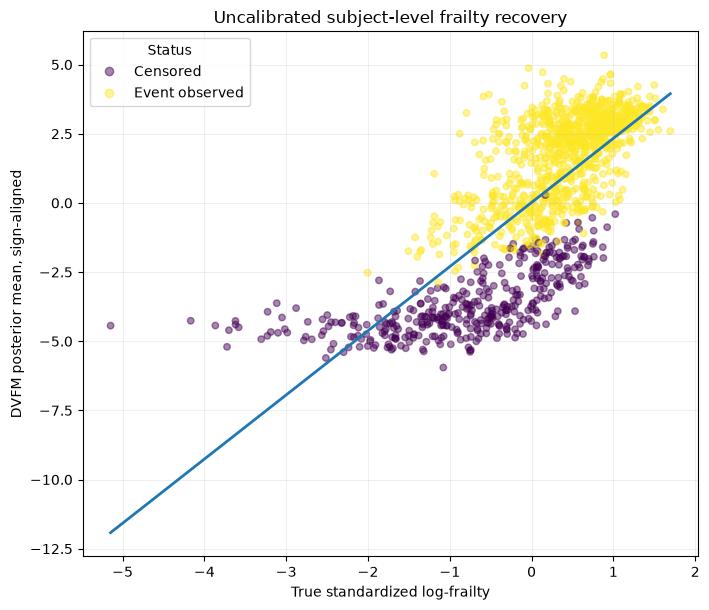

In [13]:
x = test["true_z"].to_numpy()
y = test["learned_mu_aligned"].to_numpy()

line = LinearRegression().fit(x.reshape(-1, 1), y)
grid = np.linspace(x.min(), x.max(), 200)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
scatter = ax.scatter(
    x,
    y,
    c=test["event"],
    alpha=0.48,
    s=22,
)
ax.plot(grid, line.predict(grid.reshape(-1, 1)), linewidth=2)
ax.set_xlabel("True standardized log-frailty")
ax.set_ylabel("DVFM posterior mean, sign-aligned")
ax.set_title("Uncalibrated subject-level frailty recovery")
ax.grid(alpha=0.2)

handles, _ = scatter.legend_elements()
ax.legend(handles, ["Censored", "Event observed"], title="Status")
fig.tight_layout()
plt.show()

## Calibrated subject-level recovery

Both axes are now on the standardized log-frailty scale. The dashed identity line represents perfect recovery. The calibration was learned on validation data, not on these test points.

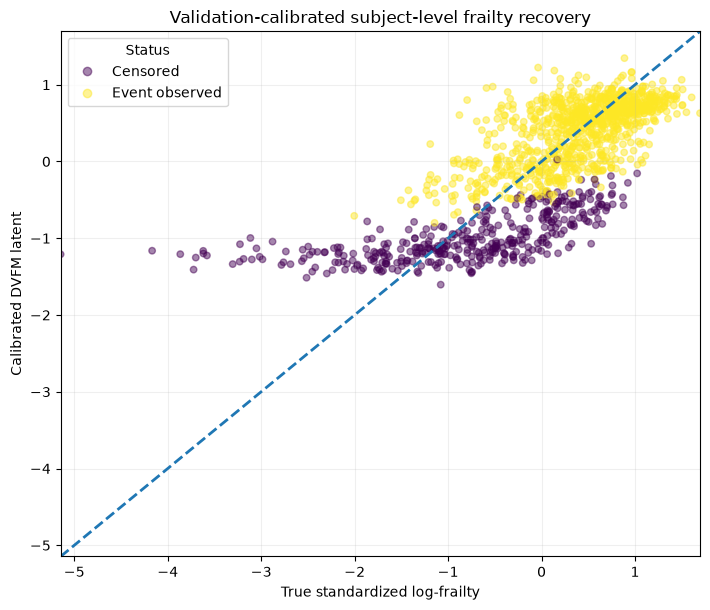

In [7]:
x = test["true_z"].to_numpy()
y = test["learned_z_calibrated"].to_numpy()

lower = min(x.min(), y.min())
upper = max(x.max(), y.max())

fig, ax = plt.subplots(figsize=(7.2, 6.2))
scatter = ax.scatter(
    x,
    y,
    c=test["event"],
    alpha=0.48,
    s=22,
)
ax.plot([lower, upper], [lower, upper], linestyle="--", linewidth=2)
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("True standardized log-frailty")
ax.set_ylabel("Calibrated DVFM latent")
ax.set_title("Validation-calibrated subject-level frailty recovery")
ax.grid(alpha=0.2)

handles, _ = scatter.legend_elements()
ax.legend(handles, ["Censored", "Event observed"], title="Status")
fig.tight_layout()
plt.show()

## Calibration by frailty decile

This plot summarizes whether the calibrated latent is correct on average across the frailty distribution. Points close to the identity line indicate good group-level calibration.

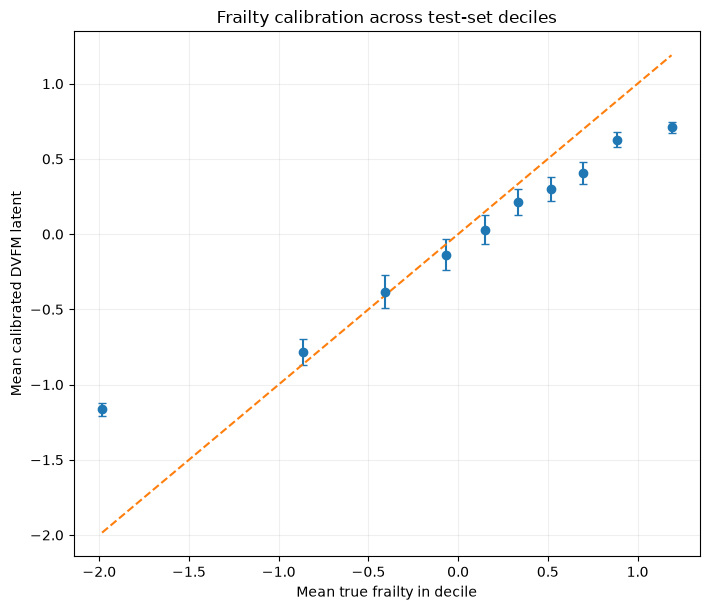

,true_z_mean,calibrated_mean,calibrated_sd,n,sem
0,-1.984033,-1.164647,0.247825,134,0.021409
1,-0.867060,-0.784792,0.505044,133,0.043793
2,-0.407638,-0.382113,0.641802,133,0.055651
3,-0.069781,-0.136332,0.610620,133,0.052948
4,0.150630,0.028657,0.567614,133,0.049218
5,0.331530,0.213896,0.511852,133,0.044383
6,0.515092,0.300149,0.475770,133,0.041254
7,0.695736,0.405082,0.426997,133,0.037025
8,0.887361,0.626592,0.294560,133,0.025542
9,1.189318,0.709717,0.209468,133,0.018163


In [8]:
deciles = pd.qcut(
    test["true_z"],
    q=10,
    duplicates="drop",
)

binned = (
    test.assign(true_z_decile=deciles)
    .groupby("true_z_decile", observed=True)
    .agg(
        true_z_mean=("true_z", "mean"),
        calibrated_mean=("learned_z_calibrated", "mean"),
        calibrated_sd=("learned_z_calibrated", "std"),
        n=("true_z", "size"),
    )
    .reset_index(drop=True)
)
binned["sem"] = binned["calibrated_sd"] / np.sqrt(binned["n"])

lower = min(binned["true_z_mean"].min(), binned["calibrated_mean"].min())
upper = max(binned["true_z_mean"].max(), binned["calibrated_mean"].max())

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.errorbar(
    binned["true_z_mean"],
    binned["calibrated_mean"],
    yerr=1.96 * binned["sem"],
    fmt="o",
    capsize=3,
)
ax.plot([lower, upper], [lower, upper], linestyle="--")
ax.set_xlabel("Mean true frailty in decile")
ax.set_ylabel("Mean calibrated DVFM latent")
ax.set_title("Frailty calibration across test-set deciles")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

binned

## Posterior interval coverage

The following is an exploratory check of whether the transformed posterior standard deviations yield intervals that cover the true latent at the advertised rate. Affine calibration of the mean and standard deviation does not guarantee posterior calibration, so substantial under- or over-coverage is possible.

In [9]:
covered = (
    (test["true_z"] >= test["calibrated_lower_95"])
    & (test["true_z"] <= test["calibrated_upper_95"])
)

coverage = float(covered.mean())
mean_width = float(
    (test["calibrated_upper_95"] - test["calibrated_lower_95"]).mean()
)

coverage_by_status = (
    test.assign(covered_95=covered)
    .groupby("event")
    .agg(
        coverage_95=("covered_95", "mean"),
        mean_interval_width=(
            "calibrated_upper_95",
            lambda s: np.nan,
        ),
        n=("covered_95", "size"),
    )
)

# Compute interval width cleanly by status.
coverage_by_status = (
    test.assign(
        covered_95=covered,
        interval_width=(
            test["calibrated_upper_95"] - test["calibrated_lower_95"]
        ),
    )
    .groupby("event")
    .agg(
        coverage_95=("covered_95", "mean"),
        mean_interval_width=("interval_width", "mean"),
        n=("covered_95", "size"),
    )
    .rename(index={0: "Censored", 1: "Event observed"})
)

print(f"Overall empirical 95% coverage: {coverage:.3f}")
print(f"Mean calibrated interval width: {mean_width:.3f}")
coverage_by_status

Overall empirical 95% coverage: 0.201
Mean calibrated interval width: 0.268


,coverage_95,mean_interval_width,n
event,,,
Censored,0.145363,0.287845,399
Event observed,0.224249,0.259852,932


## Save calibrated subject-level outputs

The saved test CSV contains the validation-derived calibrated latent, transformed posterior standard deviation, and exploratory 95% interval for every test subject.

In [10]:
valid_out = OUTPUT_DIR / "latent_recovery_validation_calibrated.csv"
test_out = OUTPUT_DIR / "latent_recovery_test_calibrated.csv"
metrics_out = OUTPUT_DIR / "latent_calibration_metrics.csv"

valid.to_csv(valid_out, index=False)
test.to_csv(test_out, index=False)
metrics.to_csv(metrics_out, index=False)

print(f"Saved: {valid_out}")
print(f"Saved: {test_out}")
print(f"Saved: {metrics_out}")

Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\latent_recovery_validation_calibrated.csv
Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\latent_recovery_test_calibrated.csv
Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\latent_calibration_metrics.csv
